## Phase-1: DATA EXPLORATION
### Goal: Understand our sales data - what do we have, what patterns exist?

In [1]:
import os
# Ensure CWD is always the project root regardless of how the notebook is launched
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f'Working directory: {os.getcwd()}')


Working directory: /Users/paarth_ganesh/Documents/ML-Projects/sales-forecasting-dashboard


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
"""
SETUP: Configure display and plot settings
"""

print("="*70)
print("SALES FORECASTING DASHBOARD - DATA ANALYSIS")
print("="*70)

# Pandas display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

# Seaborn style settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("\n Libraries loaded successfully!")

SALES FORECASTING DASHBOARD - DATA ANALYSIS

 Libraries loaded successfully!


In [4]:
"""
STEP 1: LOAD DATA
"""

print("\n" + "="*70)
print("STEP 1: LOADING DATA")
print("="*70)

# Load the CSV file
df = pd.read_csv('data/raw/sales_data.csv')

print(f"\n Data loaded successfully!")
print(f" Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f" Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f" Total Sales: ${df['Sales'].sum():,.2f}")

print("\n" + "-"*70)
print("First 10 rows:")
print("-"*70)
print(df.head(10))

print("\n" + "-"*70)
print("Last 10 rows:")
print("-"*70)
print(df.tail(10))



STEP 1: LOADING DATA

 Data loaded successfully!
 Dataset Shape: 17520 rows x 4 columns
 Date Range: 2021-01-01 to 2023-12-31
 Total Sales: $25,198,344.29

----------------------------------------------------------------------
First 10 rows:
----------------------------------------------------------------------
         Date      Product Region    Sales
0  2021-01-01  Electronics  North  1742.99
1  2021-01-01  Electronics  South  1400.06
2  2021-01-01  Electronics   East  1568.32
3  2021-01-01  Electronics   West  1769.42
4  2021-01-01     Clothing  North   877.64
5  2021-01-01     Clothing  South   728.76
6  2021-01-01     Clothing   East   910.54
7  2021-01-01     Clothing   West   922.02
8  2021-01-01         Food  North   819.65
9  2021-01-01         Food  South   737.07

----------------------------------------------------------------------
Last 10 rows:
----------------------------------------------------------------------
             Date    Product Region    Sales
17510  2023

In [5]:
"""
STEP 2: DATA TYPES AND CONVERSION
"""

print("="*70)
print("DATA TYPES:")
print("="*70)
print(df.dtypes)

print("\n" + "="*70)
print("DETAILED INFO:")
print("="*70)
df.info()

DATA TYPES:
Date        object
Product     object
Region      object
Sales      float64
dtype: object

DETAILED INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     17520 non-null  object 
 1   Product  17520 non-null  object 
 2   Region   17520 non-null  object 
 3   Sales    17520 non-null  float64
dtypes: float64(1), object(3)
memory usage: 547.6+ KB


In [6]:
"""
STEP 3: MISSING VALUES CHECK
"""

print("\n" + "="*70)
print("STEP 3: CHECKING FOR MISSING VALUES")
print("="*70)

missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing)

missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nMissing values (%):")
print(missing_pct)

total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print("\n Excellent! No missing values found!")
else:
    print(f"\n Warning: {total_missing} missing values detected!")


STEP 3: CHECKING FOR MISSING VALUES

Missing values per column:
Date       0
Product    0
Region     0
Sales      0
dtype: int64

Missing values (%):
Date       0.0
Product    0.0
Region     0.0
Sales      0.0
dtype: float64

 Excellent! No missing values found!


In [7]:
"""
# STEP 4: STATISTICAL SUMMARY
"""

print("\n" + "="*70)
print("STEP 4: STATISTICAL ANALYSIS")
print("="*70)

print("\nBasic statistics:")
print(df.describe())

print("\n" + "-"*70)
print("DETAILED SALES STATISTICS:")
print("-"*70)
print(f"Mean (Average):      ${df['Sales'].mean():,.2f}")
print(f"Median (Middle):     ${df['Sales'].median():,.2f}")
print(f"Mode (Most Common):  ${df['Sales'].mode()[0]:,.2f}")
print(f"Std Dev (Spread):    ${df['Sales'].std():,.2f}")
print(f"Minimum:             ${df['Sales'].min():,.2f}")
print(f"Maximum:             ${df['Sales'].max():,.2f}")
print(f"Range:               ${df['Sales'].max() - df['Sales'].min():,.2f}")

# Quartiles
q1 = df['Sales'].quantile(0.25)
q2 = df['Sales'].quantile(0.50)
q3 = df['Sales'].quantile(0.75)
iqr = q3 - q1
print(f"\n25th Percentile (Q1): ${q1:,.2f}")
print(f"50th Percentile (Q2): ${q2:,.2f}")
print(f"75th Percentile (Q3): ${q3:,.2f}")
print(f"IQR (Q3-Q1):          ${iqr:,.2f}")


STEP 4: STATISTICAL ANALYSIS

Basic statistics:
              Sales
count  17520.000000
mean    1438.261660
std      327.832884
min      543.890000
25%     1208.027500
50%     1429.440000
75%     1655.407500
max     2668.870000

----------------------------------------------------------------------
DETAILED SALES STATISTICS:
----------------------------------------------------------------------
Mean (Average):      $1,438.26
Median (Middle):     $1,429.44
Mode (Most Common):  $1,182.05
Std Dev (Spread):    $327.83
Minimum:             $543.89
Maximum:             $2,668.87
Range:               $2,124.98

25th Percentile (Q1): $1,208.03
50th Percentile (Q2): $1,429.44
75th Percentile (Q3): $1,655.41
IQR (Q3-Q1):          $447.38



STEP 5: CATEGORICAL DATA ANALYSIS

Product Distribution:
Product
Electronics    4380
Clothing       4380
Food           4380
Furniture      4380
Name: count, dtype: int64

Product Percentages:
Product
Electronics    25.0
Clothing       25.0
Food           25.0
Furniture      25.0
Name: proportion, dtype: float64

----------------------------------------------------------------------
Region Distribution:
Region
North    4380
South    4380
East     4380
West     4380
Name: count, dtype: int64

Region Percentages:
Region
North    25.0
South    25.0
East     25.0
West     25.0
Name: proportion, dtype: float64


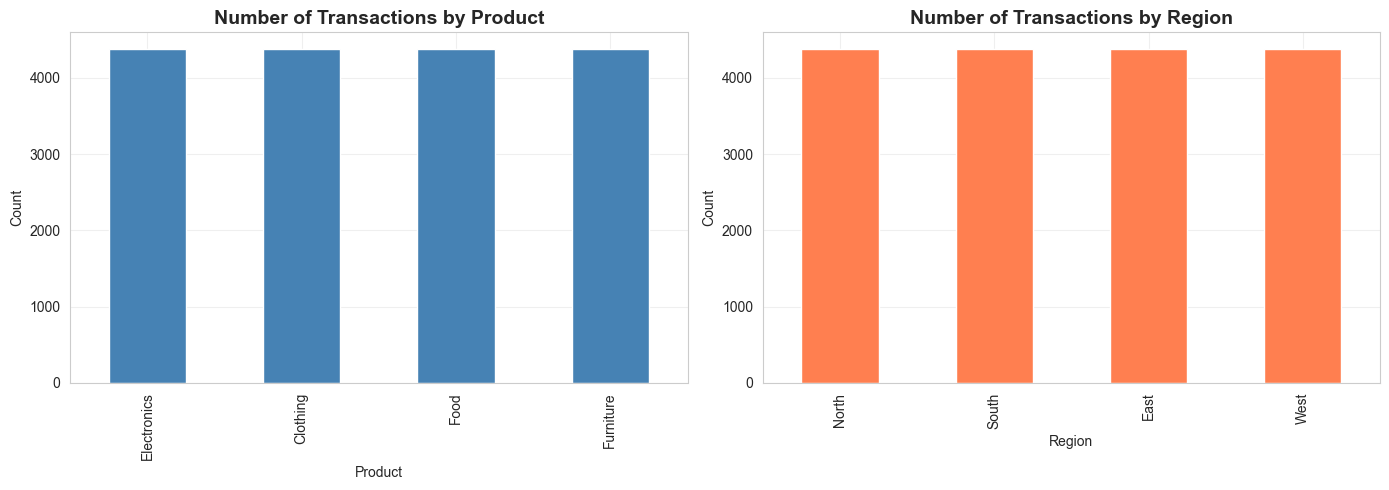


Visualization complete!


In [8]:
"""
STEP 5: CATEGORICAL ANALYSIS
"""

print("\n" + "="*70)
print("STEP 5: CATEGORICAL DATA ANALYSIS")
print("="*70)

print("\nProduct Distribution:")
print(df['Product'].value_counts())

print("\nProduct Percentages:")
product_pct = df['Product'].value_counts(normalize=True) * 100
print(product_pct)

print("\n" + "-"*70)
print("Region Distribution:")
print(df['Region'].value_counts())

print("\nRegion Percentages:")
region_pct = df['Region'].value_counts(normalize=True) * 100
print(region_pct)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Product bar chart
df['Product'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Transactions by Product', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Region bar chart
df['Region'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Number of Transactions by Region', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

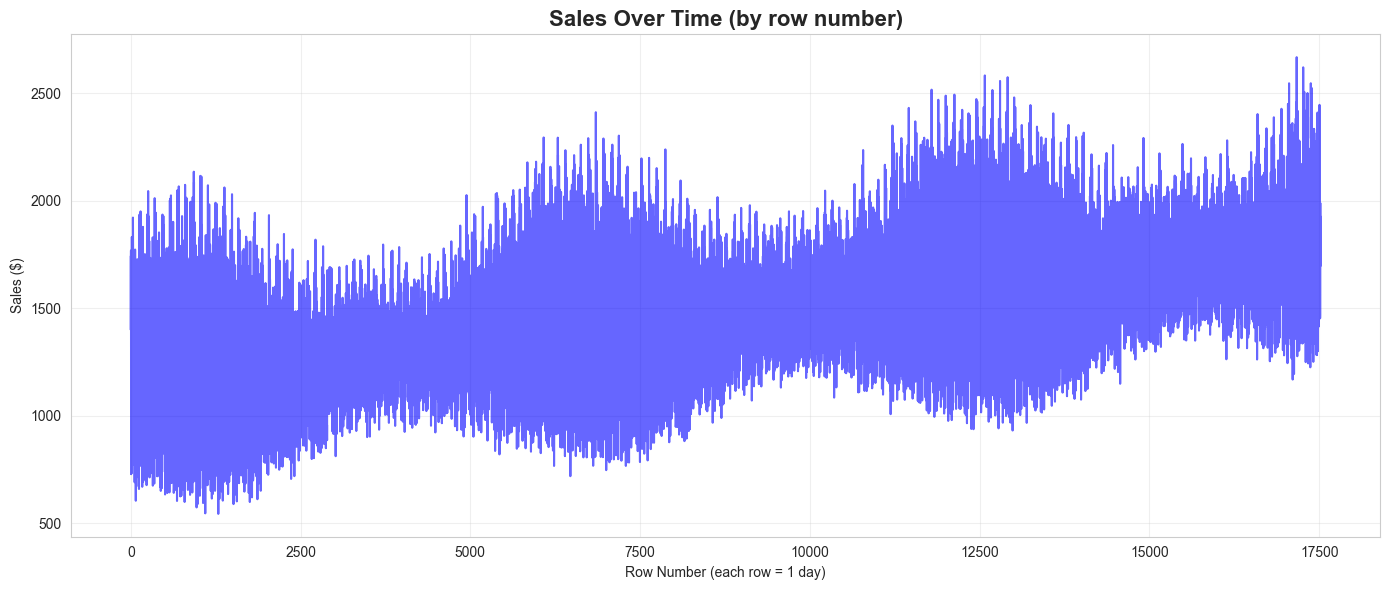

Basic sales plot created!

TIP: We can see an upward trend! Sales are growing.
We'll make better time-based plots in the next notebook.


In [9]:
"""
STEP 6: FIRST SALES VISUALIZATION
"""
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Sales'], alpha=0.6, color='blue')
plt.title('Sales Over Time (by row number)', fontsize=16, fontweight='bold')
plt.xlabel('Row Number (each row = 1 day)')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Basic sales plot created!")
print("\nTIP: We can see an upward trend! Sales are growing.")
print("We'll make better time-based plots in the next notebook.")

In [10]:
"""
PHASE 1 COMPLETE: Summary of what we learned
"""

print("="*70)
print("PHASE 1: DATA EXPLORATION - SUMMARY")
print("="*70)

print("\nWHAT WE DISCOVERED:")
print(f"  1. Dataset has {len(df):,} rows ({df['Product'].nunique()} products × {df['Region'].nunique()} regions × {df['Date'].nunique()} unique dates)")
print("  2. 4 columns: Date, Product, Region, Sales")
print("  3. No missing values (great!)")
print("  4. Sales range from ${:,.2f} to ${:,.2f}".format(df['Sales'].min(), df['Sales'].max()))
print("  5. Average daily sales: ${:,.2f}".format(df['Sales'].mean()))
print("  6. Products and Regions are balanced (roughly equal)")
print("  7. Clear upward trend in sales (business is growing!)")

print("\nISSUES FOUND:")
print("  1. Date column is 'object' type - needs to be datetime")

print("\nNEXT STEPS (Phase 2 - Data Cleaning):")
print("  1. Convert Date to proper datetime format")
print("  2. Sort data by date")
print("  3. Save cleaned dataset to data/processed/sales_data_clean.csv")

print("\n" + "="*70)
print("PHASE 1 COMPLETE! Ready for Phase 2.")
print("="*70)

PHASE 1: DATA EXPLORATION - SUMMARY

WHAT WE DISCOVERED:
  1. Dataset has 1,096 rows (3 years of daily sales)
  2. 4 columns: Date, Product, Region, Sales
  3. No missing values (great!)
  4. Sales range from $543.89 to $2,668.87
  5. Average daily sales: $1,438.26
  6. Products and Regions are balanced (roughly equal)
  7. Clear upward trend in sales (business is growing!)

ISSUES FOUND:
  1. Date column is 'object' type - needs to be datetime

NEXT STEPS (Phase 2 - Data Cleaning):
  1. Convert Date to proper datetime format
  2. Sort data by date
  3. Extract time features (month, year, day of week)
  4. Save cleaned data

PHASE 1 COMPLETE! Ready for Phase 2.
